In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 

In [2]:
from OceanDataStore import OceanDataCatalog

In [3]:
catalog = OceanDataCatalog(catalog_name="noc-model-stac")

In [4]:
catalog.available_collections

['noc-rapid-evolution', 'noc-npd-jra55', 'noc-npd-era5']

In [5]:
catalog.search(collection='noc-npd-era5', standard_name='sea_surface_temperature')


            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1y
              Title: eORCA1 ERA5v1 NPD T1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics annual mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2024-12-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1m
              Title: eORCA1 ERA5v1 NPD T1m Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics monthly mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2024-12-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca025-era5v1/gn/T1y_3d
              Title: eORCA025 ERA5v1 NPD T1y_3d Icechunk repository
              Description: Icechunk repository containing eORCA025 ERA5v1 

In [6]:
catalog.available_items

['noc-npd-era5/npd-eorca1-era5v1/gn/T1y',
 'noc-npd-era5/npd-eorca1-era5v1/gn/T1m',
 'noc-npd-era5/npd-eorca025-era5v1/gn/T1y_3d',
 'noc-npd-era5/npd-eorca025-era5v1/gn/T1m_3d',
 'noc-npd-era5/npd-eorca025-era5v1/gn/T5d_3d',
 'noc-npd-era5/npd-eorca12-era5v1/gn/T1y_3d',
 'noc-npd-era5/npd-eorca12-era5v1/gn/T1m_3d']

In [7]:
catalog.Items[0]

<Item id=noc-npd-era5/npd-eorca1-era5v1/gn/T1y>

In [8]:
ds1 = catalog.open_dataset(id=catalog.Items[0].id,
                          start_datetime='1980-01',
                          end_datetime='1990-12',
                          )

ds1

<xarray.Dataset> Size: 9GB
Dimensions:                (time_counter: 11, y: 331, x: 360, deptht: 75,
                            axis_nbounds: 2)
Coordinates:
  * deptht                 (deptht) float32 300B 0.5058 1.556 ... 5.902e+03
    nav_lat                (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    nav_lon                (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    time_centered          (time_counter) datetime64[ns] 88B dask.array<chunksize=(1,), meta=np.ndarray>
  * time_counter           (time_counter) datetime64[ns] 88B 1980-07-02 ... 1...
Dimensions without coordinates: y, x, axis_nbounds
Data variables: (12/73)
    berg_latent_heat_flux  (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    ficeberg               (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    e3t                    (time_counter, deptht, y, x) float32 393MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    empmr                  (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    hfempds                (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    evs                    (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    ...                     ...
    time_counter_bounds    (time_counter, axis_nbounds) datetime64[ns] 176B dask.array<chunksize=(1, 2), meta=np.ndarray>
    vowflisf               (time_counter, deptht, y, x) float32 393MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    vohflisf               (time_counter, deptht, y, x) float32 393MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    vohfcisf               (time_counter, deptht, y, x) float32 393MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    zossq                  (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    zos                    (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>

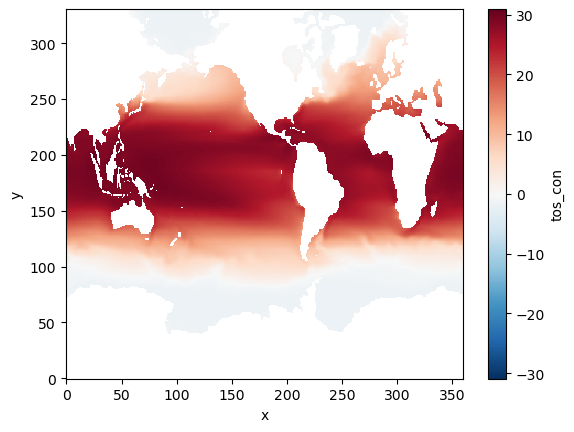

In [9]:
## First Plot to test - entire map, time averaged between 1980 - 1990

ds1['tos_con'].mean(dim='time_counter').plot(cmap='RdBu_r')

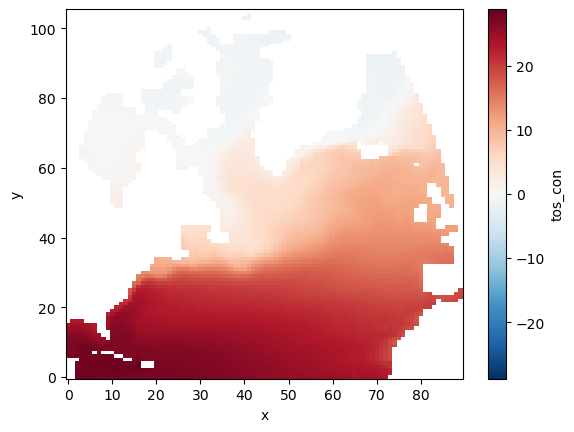

In [14]:
ds2 = catalog.open_dataset(id=catalog.Items[0].id,
                          start_datetime='1980-01',
                          end_datetime='1990-12',
                          bbox = (-90.0, 15.0, 0.0, 80.0))

ds2['tos_con'].mean(dim='time_counter').plot(cmap='RdBu_r')

In [15]:
print(ds2['tos_con'].coords)
print(ds2['tos_con'].dims)

Coordinates:
    nav_lon        (y, x) float64 76kB -89.5 -88.5 -87.5 ... 49.57 50.62 51.59
    nav_lat        (y, x) float64 76kB 15.82 15.82 15.82 ... 80.47 80.05 79.63
    time_centered  (time_counter) datetime64[ns] 88B dask.array<chunksize=(1,), meta=np.ndarray>
  * time_counter   (time_counter) datetime64[ns] 88B 1980-07-02 ... 1990-07-0...
('time_counter', 'y', 'x')
